In [1]:
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import accuracy_score,classification_report
from sklearn.linear_model import LogisticRegression 


In [2]:
df=pd.read_csv("./data/Churn_Modelling.csv")

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop(["RowNumber","CustomerId","Surname"],axis=1,inplace=True)

In [8]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [12]:
df_transformed=pd.get_dummies(df,columns=["Gender","Geography"],drop_first=True,dtype=np.int64)

In [13]:
df_transformed

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,1,0


In [23]:
x=df_transformed.iloc[:,[0,1,2,3,4,5,6,7,9,10,11]]
y=df_transformed.iloc[:,8]

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [25]:
st_balance=StandardScaler()
x_train=st_balance.fit_transform(x_train)
x_test=st_balance.transform(x_test)


In [32]:
import tensorflow
import keras
from keras import Sequential
from keras.layers import Dense

In [33]:
model=Sequential()
model.add(Dense(3,activation='sigmoid',input_dim=11))
model.add(Dense(1,activation='sigmoid'))

c:\Users\Jainam Harsh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [36]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6264
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5149
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4789
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4592
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4564
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4573
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4484
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4489
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4259
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4283


In [37]:
model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.11379808],
       [0.13887042],
       [0.13629413],
       ...,
       [0.07305119],
       [0.13939962],
       [0.34962785]], dtype=float32)

In [38]:
model.weights

[<KerasVariable shape=(11, 3), dtype=float32, path=sequential/dense/kernel>,
 <KerasVariable shape=(3,), dtype=float32, path=sequential/dense/bias>,
 <KerasVariable shape=(3, 1), dtype=float32, path=sequential/dense_1/kernel>,
 <KerasVariable shape=(1,), dtype=float32, path=sequential/dense_1/bias>]

In [39]:
model.layers[0].get_weights()

[array([[ 0.03397365, -0.47652328,  0.09752354],
        [-1.9090037 , -0.27881315, -1.2336743 ],
        [ 0.16821843, -0.67135674, -0.09751185],
        [-0.42662412,  0.7342276 , -0.2218275 ],
        [ 0.13779332, -0.11981189,  0.04518938],
        [ 0.11568674,  0.00644531, -0.0296443 ],
        [ 0.56750524,  0.2964147 ,  0.91843486],
        [ 0.02704736, -0.5491638 , -0.09105361],
        [ 0.69867784, -0.25533745,  0.39258364],
        [-0.7594334 , -0.32522574, -0.48822588],
        [-0.2383325 , -0.15015048,  0.19785576]], dtype=float32),
 array([ 0.412911  , -0.21555233,  0.37710336], dtype=float32)]

In [41]:
model.layers[1].get_weights()

[array([[-0.9887323 ],
        [ 0.05131582],
        [-1.4610772 ]], dtype=float32),
 array([-0.21157609], dtype=float32)]

In [42]:
y_log=model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [52]:
y_log[y_log>0.5]

array([], dtype=float32)

In [44]:
y_log_prediction=np.where(y_log>0.5,1,0)

In [49]:
np.unique(y_log_prediction)

array([0])

In [53]:

accuracy_score(y_test,y_log_prediction)

0.7925

In [54]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\Jainam Harsh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [61]:
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8679 - loss: 0.3164 - val_accuracy: 0.8500 - val_loss: 0.3528
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8705 - loss: 0.3103 - val_accuracy: 0.8481 - val_loss: 0.3539
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8753 - loss: 0.2980 - val_accuracy: 0.8469 - val_loss: 0.3538
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8701 - loss: 0.3090 - val_accuracy: 0.8475 - val_loss: 0.3544
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8681 - loss: 0.3221 - val_accuracy: 0.8475 - val_loss: 0.3554
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8693 - loss: 0.3123 - val_accuracy: 0.8462 - val_loss: 0.3569
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8569 - loss: 0.3316 - val_accuracy: 0.8500 - val_loss: 0.3547
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8726 - loss: 0.3084 - val_accu

In [62]:
y_log=model.predict(x_test)
y_log_prediction=np.where(y_log>0.5,1,0)
accuracy_score(y_test,y_log_prediction)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.8605

In [64]:
history.history

{'accuracy': [0.8675000071525574,
  0.8693749904632568,
  0.867968738079071,
  0.8698437213897705,
  0.8684375286102295,
  0.8682812452316284,
  0.8675000071525574,
  0.8707812428474426,
  0.8685937523841858,
  0.8676562309265137,
  0.8682812452316284,
  0.867968738079071,
  0.8692187666893005,
  0.870312511920929,
  0.8692187666893005,
  0.8681250214576721,
  0.8695312738418579,
  0.8682812452316284,
  0.8690624833106995,
  0.8700000047683716,
  0.8693749904632568,
  0.8695312738418579,
  0.8682812452316284,
  0.8682812452316284,
  0.8685937523841858,
  0.8675000071525574,
  0.866406261920929,
  0.8693749904632568,
  0.8690624833106995,
  0.8682812452316284,
  0.8685937523841858,
  0.8707812428474426,
  0.8675000071525574,
  0.8693749904632568,
  0.8692187666893005,
  0.8690624833106995,
  0.8700000047683716,
  0.8685937523841858,
  0.8687499761581421,
  0.8704687356948853,
  0.8712499737739563,
  0.8667187690734863,
  0.8696874976158142,
  0.8714062571525574,
  0.8712499737739563,
  

<Axes: >

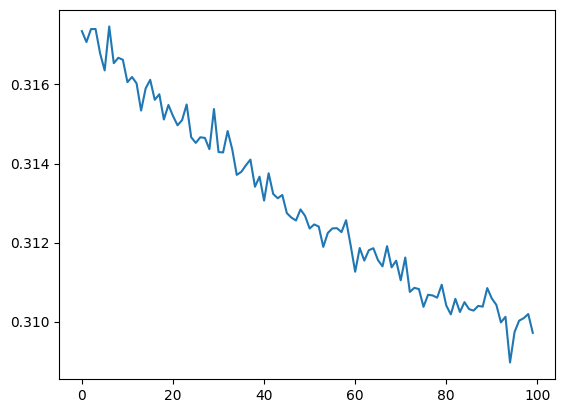

In [68]:
sns.lineplot(history.history['loss'])

<Axes: >

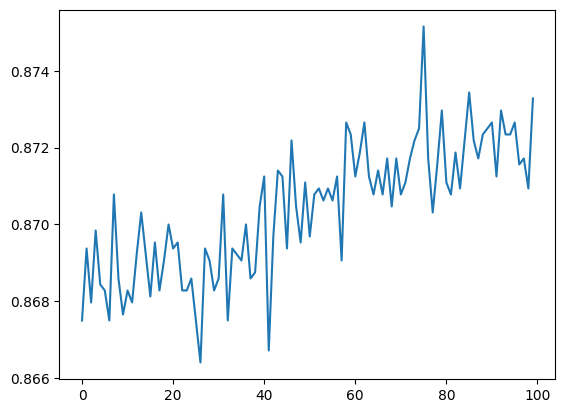

In [69]:
sns.lineplot(history.history['accuracy'])

In [70]:
import plotly


In [74]:
plotly.plot(history.history['accuracy'],kind='line')


In [77]:
plotly.plot(history.history['loss'],kind='line')
plotly.plot(history.history['val_loss'],kind='line')


